# Proyecto 7 - Explorando factores de comportamiento en NovaRetail+


NovaRetail+ es una plataforma de comercio electrónico en Latinoamérica con millones de usuarios.

Para el cierre de 2024, el equipo de **Crecimiento y retención** tiene como objetivo responder:

**¿Qué factores del comportamiento del cliente están más fuertemente asociados con el ingreso anual generado?**

> Este proyecto es un análisis **correlacional** (exploratorio).  
> **Correlación ≠ causalidad.**

## Sección 1 - Cargar y explorar el dataset

En esta sección validamos:
- que el dataset cargue correctamente
- tipos de datos
- valores faltantes / rangos generales

Antes de correlacionar, primero entendemos el “terreno”.

In [24]:
# Importar librerías
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np



### Cargar Dataset

#### Descripción del conjunto de datos

El dataset contiene las siguientes columnas:

- `id_cliente` — Identificador único del cliente.
- `edad` — Edad del cliente.
- `nivel_ingreso` — Ingreso anual estimado del cliente.
- `visitas_mes` — Número de visitas a la aplicación o sitio web durante el mes.
- `compras_mes` — Número de compras realizadas en el mes.
- `gasto_publicidad_dirigida` — Gasto en anuncios asignado al usuario.
- `satisfaccion` — Calificación de satisfacción del cliente en una escala del 1 al 5.
- `miembro_premium` — Indica si el cliente tiene suscripción premium (1) o no (0).
- `abandono` — Indica si el cliente abandonó la plataforma (1) o no (0).
- `tipo_dispositivo` — Tipo de dispositivo utilizado por el cliente (móvil, escritorio o tablet).
- `region` — Región geográfica del cliente (norte, sur, oeste o este).
- `ingreso_anual` — Ingreso anual generado por el cliente para la empresa.

La métrica principal de análisis es `ingreso_anual`, utilizada para evaluar el impacto económico de los clientes.


In [25]:
# Cargar el dataset y explorar datos
df = pd.read_csv('/datasets/novaretail_comportamiento_clientes_2024.csv')
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15000 entries, 0 to 14999
Data columns (total 12 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   id_cliente                 15000 non-null  object 
 1   edad                       15000 non-null  float64
 2   nivel_ingreso              15000 non-null  float64
 3   visitas_mes                15000 non-null  int64  
 4   compras_mes                15000 non-null  int64  
 5   gasto_publicidad_dirigida  15000 non-null  float64
 6   satisfaccion               15000 non-null  float64
 7   miembro_premium            15000 non-null  int64  
 8   abandono                   15000 non-null  int64  
 9   tipo_dispositivo           15000 non-null  object 
 10  region                     15000 non-null  object 
 11  ingreso_anual              15000 non-null  float64
dtypes: float64(5), int64(4), object(3)
memory usage: 1.4+ MB


In [26]:
# mostrar las primeras 5 filas
df.head(5)

,id_cliente,edad,nivel_ingreso,visitas_mes,compras_mes,gasto_publicidad_dirigida,satisfaccion,miembro_premium,abandono,tipo_dispositivo,region,ingreso_anual
0,CL-100000,44.0,28565.77,9,1,31.36,3.9,0,0,móvil,norte,23.22
1,CL-100001,36.0,29673.44,11,3,24.66,3.7,0,0,tablet,sur,93.47
2,CL-100002,46.0,30642.95,9,0,0.00,2.9,0,0,móvil,este,0.00
3,CL-100003,56.0,39468.61,8,0,6.81,3.1,0,0,móvil,este,0.00
4,CL-100004,35.0,22527.83,9,2,26.49,2.3,0,0,móvil,sur,33.76


## Sección 2 - Preparar datos y documentar supuestos

### Exploración y Limpieza

💡
Después de analizar la información anterior, completa la siguiente sección.  
- Si aplica, señala la o las columnas que requieren algun cambio

Recuerda eliminar este bloque de texto antes de subir el proyecto a tu portafolio.


#### Exploración inicial de los datos
El conjunto de datos contiene **15,000 registros** y **12 columnas**, sin valores nulos.

**Variables numéricas**  
Se identifican las siguientes columnas numéricas:
- `edad`
- 

La mayoría de estas variables presentan tipos de datos adecuados.  
La columna ... .


**Variables binarias**  
Las siguientes columnas representan variables binarias:
- `miembro_premium`
- `abandono`

Ambas están codificadas como 0 y 1, **no requieren transformación adicional**.

**Variables categóricas**  
Se identifican las siguientes columnas categóricas:
- `id_cliente`
- `tipo_dispositivo`
- `region`

Estas variables están correctamente definidas y no requieren transformación adicional.

In [27]:
# Corregir el tipo de dato
# No fue necesario corregir tipos de datos, ya que todas las columnas tienen el formato adecuado.



In [28]:
# verificar cambios
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15000 entries, 0 to 14999
Data columns (total 12 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   id_cliente                 15000 non-null  object 
 1   edad                       15000 non-null  float64
 2   nivel_ingreso              15000 non-null  float64
 3   visitas_mes                15000 non-null  int64  
 4   compras_mes                15000 non-null  int64  
 5   gasto_publicidad_dirigida  15000 non-null  float64
 6   satisfaccion               15000 non-null  float64
 7   miembro_premium            15000 non-null  int64  
 8   abandono                   15000 non-null  int64  
 9   tipo_dispositivo           15000 non-null  object 
 10  region                     15000 non-null  object 
 11  ingreso_anual              15000 non-null  float64
dtypes: float64(5), int64(4), object(3)
memory usage: 1.4+ MB


#### Explorar variables numéricas

In [29]:
# Estadísticas descriptivas de variables numéricas
df.describe()


,edad,nivel_ingreso,visitas_mes,compras_mes,gasto_publicidad_dirigida,satisfaccion,miembro_premium,abandono,ingreso_anual
count,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000
mean,38.262400,30019.704782,10.029000,1.206467,20.149301,3.603693,0.139267,0.150733,36.594180
std,11.492378,9833.166305,3.158189,1.105284,10.880724,0.685300,0.346236,0.357801,34.484888
min,18.000000,8000.000000,1.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000
25%,30.000000,23127.097500,8.000000,0.000000,12.310000,3.100000,0.000000,0.000000,0.000000
50%,38.000000,30023.745000,10.000000,1.000000,19.730000,3.600000,0.000000,0.000000,30.705000
75%,46.000000,36768.440000,12.000000,2.000000,27.292500,4.100000,0.000000,0.000000,58.220000
max,75.000000,74790.840000,25.000000,8.000000,75.510000,5.000000,1.000000,1.000000,244.690000


✍️ **Comentario**: Haz doble clic en este bloque y escribe tu diagnóstico.  
Incluye qué ves (resalta un detalle relevante por columna)

Diagnóstico de las variables numéricas

A partir de las estadísticas descriptivas se observa lo siguiente:

La edad de los clientes oscila entre 18 y 75 años, con una media de 38.26 años y una mediana de 38 años, lo que indica una distribución bastante equilibrada sin evidencia de sesgos importantes.
El nivel de ingreso presenta una media cercana a 30,020, con valores entre 8,000 y 74,791, reflejando una amplia diversidad económica entre los clientes.
Los clientes realizan en promedio 10 visitas mensuales a la plataforma, con un rango entre 1 y 25 visitas, lo que evidencia distintos niveles de interacción con el servicio.
El número de compras mensuales tiene una media de 1.21 compras, aunque existen clientes que no realizan compras y otros que alcanzan hasta 8 compras en un mes.
El gasto en publicidad dirigida presenta una media de 20.15 unidades monetarias, con un máximo de 75.51, indicando que algunos clientes reciben una inversión publicitaria considerablemente superior al promedio.
La satisfacción promedio es de 3.60 sobre una escala de 1 a 5, lo que sugiere un nivel de satisfacción moderadamente alto entre los clientes.
El ingreso anual presenta una gran variabilidad, con valores entre 0 y 244.69, lo que sugiere la existencia de clientes con comportamientos de compra muy diferentes y posibles valores extremos que podrían analizarse posteriormente.

Variables binarias

Las siguientes columnas representan variables binarias:

miembro_premium
abandono

Ambas están codificadas mediante los valores 0 y 1, por lo que no requieren transformación adicional.

Además, las estadísticas indican que aproximadamente:

13.9 % de los clientes pertenecen al programa Premium.
15.1 % de los clientes presentan abandono (churn).

Esto evidencia que la mayoría de los clientes no pertenece al programa Premium y que el porcentaje de abandono es relativamente bajo, aunque representa un segmento relevante para futuros análisis de retención.

Variables categóricas

Se identifican las siguientes variables categóricas:

id_cliente
tipo_dispositivo
region

Estas variables presentan el tipo de dato object, por lo que están correctamente definidas para representar categorías o identificadores.

La columna id_cliente corresponde a un identificador único y no será utilizada para análisis estadísticos, mientras que tipo_dispositivo y region podrán emplearse posteriormente para realizar segmentaciones y estudiar asociaciones entre categorías.

Diagnóstico general

El conjunto de datos presenta una buena calidad inicial, ya que no contiene valores nulos y todas las variables poseen el tipo de dato adecuado. Las estadísticas descriptivas muestran rangos coherentes para las variables numéricas, sin valores imposibles que requieran corrección inmediata. Asimismo, las variables binarias y categóricas están correctamente codificadas, lo que permite avanzar hacia el análisis exploratorio y la construcción de modelos sin necesidad de realizar procesos adicionales de limpieza estructural.

#### Explorar variables binarias

In [30]:
# Verificar que cada columna tenga únicamente dos valores posibles
columnas_binarias = ["miembro_premium", "abandono"]

for columna in columnas_binarias:
    print(f"{columna}: {df[columna].unique()}")



miembro_premium: [0 1]
abandono: [0 1]


✍️ **Comentario**: Haz doble clic en este bloque y escribe tu diagnóstico.  
Incluye qué ves (resalta un detalle relevante por columna)

Diagnóstico inicial de variables binarias

Las variables miembro_premium y abandono están correctamente codificadas, ya que únicamente contienen los valores 0 y 1, sin registros inválidos o categorías adicionales.

A partir de las estadísticas descriptivas se observa que aproximadamente el 13.9 % de los clientes pertenece al programa Premium y el 15.1 % ha abandonado el servicio. Esto indica que la mayoría de los clientes no pertenece al programa Premium y que el abandono representa una proporción relativamente baja de la base de clientes.

#### Explorar variables categóricas

In [32]:
# Verificar el número de valores únicos por variable categórica
columnas_categoricas = ["id_cliente", "tipo_dispositivo", "region"]

for columna in columnas_categoricas:
    print(f"{columna}: {df[columna].nunique()} valores únicos")

id_cliente: 15000 valores únicos
tipo_dispositivo: 3 valores únicos
region: 4 valores únicos


In [33]:
#Explorar variables categóricas y cómo se distribuyen

columnas_categoricas = ["tipo_dispositivo", "region"]

for columna in columnas_categoricas:
    print(f"\nDistribución de {columna}:")
    print(df[columna].value_counts())



Distribución de tipo_dispositivo:
móvil         9818
escritorio    3720
tablet        1462
Name: tipo_dispositivo, dtype: int64

Distribución de region:
norte    4395
oeste    3810
sur      3726
este     3069
Name: region, dtype: int64


✍️ **Comentario**: Haz doble clic en este bloque y escribe tu diagnóstico.  
Incluye qué ves (resalta un detalle relevante por columna)

Diagnóstico inicial de variables categóricas

Se verificó que las variables categóricas presentan categorías válidas y consistentes, sin registros anómalos ni valores faltantes. La columna id_cliente funciona como un identificador único para cada cliente, mientras que tipo_dispositivo y region contienen un número reducido de categorías que resultan apropiadas para realizar segmentaciones y análisis comparativos.

Además, la distribución observada indica un predominio del acceso mediante dispositivos móviles y una participación relativamente equilibrada de las distintas regiones, características que podrán aprovecharse en etapas posteriores del análisis para identificar patrones de comportamiento y oportunidades de negocio.

### Supuestos

- El análisis se realiza utilizando **todo el conjunto de datos disponible**.
- Los datos no presentan errores y están correctamente tipificados.
- Se utilizan distintos coeficientes según el tipo de variable:
  - **Pearson** asume relaciones lineales entre variables numéricas.
  - **Spearman** evalúa relaciones monótonas y no requiere normalidad.
  - **Punto biserial** se usa para relaciones numérica–binaria.
  - **Cramér (V)** se usa para asociaciones entre variables categóricas.

**Supuesto central:**  
Este análisis identifica relaciones entre variables o segmentos, pero no prueba causalidad.

## Sección 3 - Visualización de relaciones

Observamos cómo se relacionan las variables numéricas.

### Heatmap

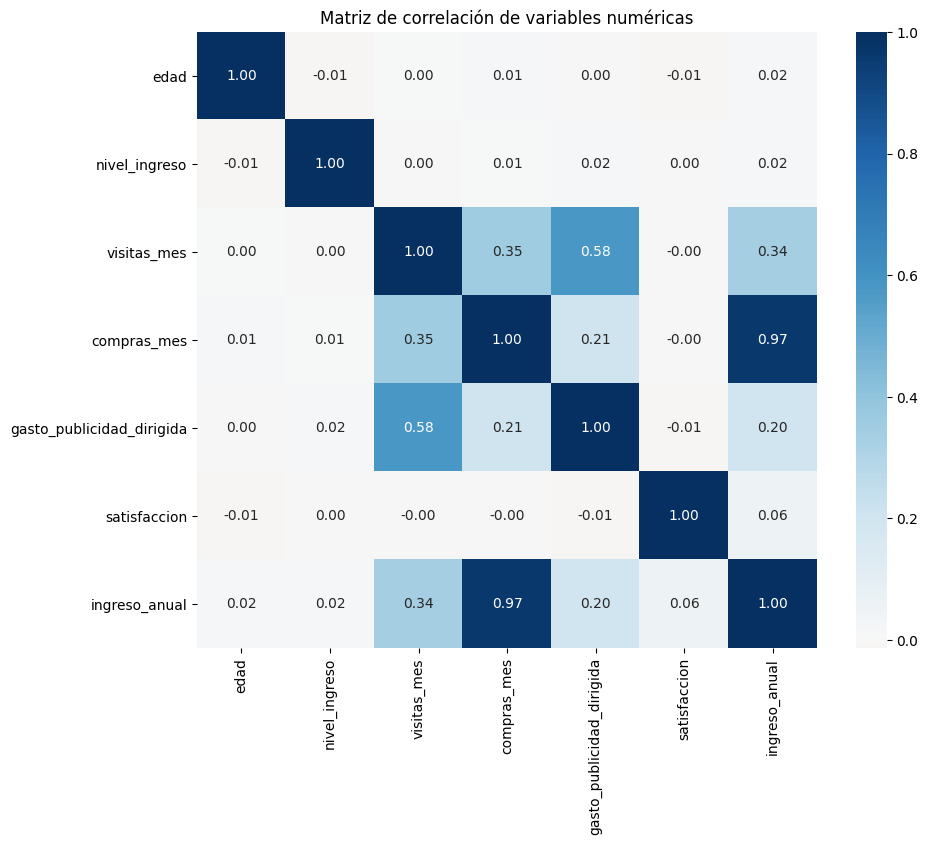

In [34]:
# Visualizar la matriz de correlación para identificar relaciones
import matplotlib.pyplot as plt
import seaborn as sns

# Seleccionar variables numéricas
columnas_numericas = [
    "edad",
    "nivel_ingreso",
    "visitas_mes",
    "compras_mes",
    "gasto_publicidad_dirigida",
    "satisfaccion",
    "ingreso_anual"
]

# Calcular matriz de correlación
corr = df[columnas_numericas].corr()

# Visualizar la matriz de correlación
plt.figure(figsize=(10, 8))
sns.heatmap(
    corr,
    annot=True,
    cmap="RdBu",
    center=0,
    fmt=".2f"
)

plt.title("Matriz de correlación de variables numéricas")
plt.show()


✍️ **Comentario**: Haz doble clic en este bloque y escribe tu diagnóstico.   
Incluye qué ves
Observaciones generales (Heatmap)  
- En términos generales, la mayoría de las variables presentan correlaciones débiles o cercanas a cero, lo que indica que no existe una relación lineal fuerte entre ellas y que cada variable aporta información diferente al análisis.
- La variable edad prácticamente no presenta correlación con las demás variables, lo que sugiere que el comportamiento de compra, las visitas, el nivel de ingreso y la satisfacción no dependen significativamente de la edad de los clientes.
- De igual forma, nivel_ingreso muestra correlaciones muy bajas con el resto de variables, indicando que el ingreso de los clientes no parece influir directamente sobre su actividad dentro de la plataforma.
- Se observa una correlación positiva moderada (0.58) entre visitas_mes y gasto_publicidad_dirigida, lo que puede indicar que los clientes que reciben mayor inversión publicitaria tienden a visitar con mayor frecuencia la plataforma.
- También existe una correlación positiva moderada (0.35) entre visitas_mes y compras_mes, lo que sugiere que un mayor número de visitas suele estar asociado con un mayor número de compras, aunque la relación no es lo suficientemente fuerte como para afirmar que una variable explica completamente la otra.
- La variable satisfacción presenta correlaciones prácticamente nulas con todas las demás variables, lo que indica que la satisfacción del cliente probablemente depende de otros factores no incluidos en este conjunto de datos, como la calidad del servicio, la atención al cliente o la experiencia de compra.

Observaciones respecto a `ingreso_anual`  
- La variable ingreso_anual presenta una correlación muy fuerte (0.97) con compras_mes.
Esta relación indica que los clientes que realizan un mayor número de compras generan mayores ingresos anuales para la empresa, lo cual es completamente coherente desde el punto de vista del negocio.
- También se observa una correlación positiva moderada (0.34) entre ingreso_anual y visitas_mes, lo que sugiere que una mayor frecuencia de visitas puede contribuir indirectamente al incremento de los ingresos, aunque el efecto es considerablemente menor que el observado con las compras.
- Finalmente, ingreso_anual presenta correlaciones muy bajas con edad, nivel_ingreso, gasto_publicidad_dirigida y satisfacción, lo que indica que estas variables no explican de manera significativa la variación de los ingresos anuales.



### Scatterplot general

Con base en los resultados del análisis de correlación, evalúa si es necesario generar un *scatterplot* general.

- **No se decide incluir**:
No se considera necesario generar un scatterplot general, ya que la matriz de correlación mostró que la mayoría de las variables presentan correlaciones débiles o prácticamente nulas. Un gráfico de dispersión para todas las variables aportaría poca información y dificultaría la interpretación de los resultados. En su lugar, se analizarán únicamente los pares de variables que presentan correlaciones moderadas o fuertes.


In [37]:
#No es necesario incluir un Scatterplot General

### Scatterplot para pares clave

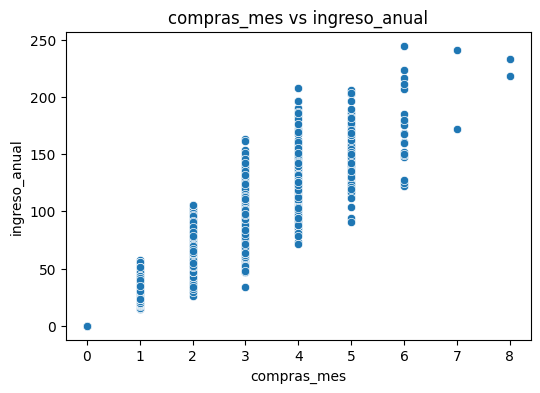

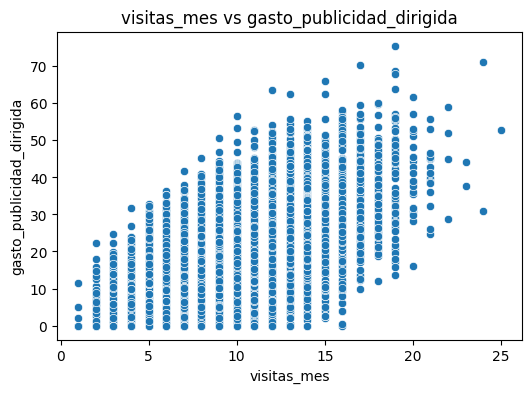

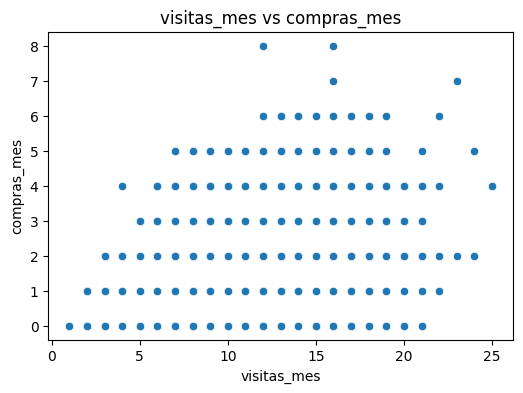

In [38]:
# Visualizar pares de variables con relaciones moderadas o fuertes
import matplotlib.pyplot as plt
import seaborn as sns

pares = [
    ("compras_mes", "ingreso_anual"),
    ("visitas_mes", "gasto_publicidad_dirigida"),
    ("visitas_mes", "compras_mes")
]

for x, y in pares:
    plt.figure(figsize=(6,4))
    sns.scatterplot(data=df, x=x, y=y)

    plt.title(f"{x} vs {y}")
    plt.xlabel(x)
    plt.ylabel(y)

    plt.show()

✍️ **Comentario**: Haz doble clic en este bloque y escribe tu diagnóstico.   
Incluye qué ves: dirección (positiva o negativa), dispersión (alta, media, baja), presencia de outliers y posible colinealidad.

Observaciones iniciales (Scatterplot)

1. compras_mes vs ingreso_anual
Dirección: Positiva muy fuerte.
Dispersión: Baja.
Outliers: No se observan outliers relevantes.
Colinealidad: Sí existe una alta colinealidad entre ambas variables.
A medida que aumenta el número de compras mensuales, también aumenta el ingreso anual generado por el cliente. La nube de puntos presenta una tendencia lineal muy marcada, consistente con la correlación de 0.97 observada en el heatmap.

2. visitas_mes vs gasto_publicidad_dirigida
Dirección: Positiva.
Dispersión: Media.
Outliers: No se observan valores atípicos significativos.
Colinealidad: No existe colinealidad alta.
Se observa una tendencia positiva moderada, indicando que los clientes con mayor inversión en publicidad dirigida tienden a visitar más la plataforma. Sin embargo, la dispersión de los datos muestra que otros factores también influyen en la cantidad de visitas.


3. visitas_mes vs compras_mes
Dirección: Positiva.
Dispersión: Media-alta.
Outliers: No se identifican outliers importantes.
Colinealidad: No existe.
Existe una relación positiva moderada entre las visitas y las compras. Los clientes que visitan con mayor frecuencia la plataforma tienden a realizar más compras, aunque la variabilidad observada indica que el número de visitas no determina completamente el comportamiento de compra.

## Sección 4 - Coeficientes de correlación y evidencia numérica

En esta sección, se reportan coeficientes que respaldan los patrones
observados visualmente, utilizando el método adecuado según el tipo
de variables.

### Pearson / Spearman

In [41]:
# Calcular correlación entre variables relevantes(pearson)

pearson_corr = df[
    [
        "visitas_mes",
        "compras_mes",
        "gasto_publicidad_dirigida",
        "ingreso_anual"
    ]
].corr(method="pearson")

print(pearson_corr)


                           visitas_mes  compras_mes  \
visitas_mes                   1.000000     0.353844   
compras_mes                   0.353844     1.000000   
gasto_publicidad_dirigida     0.578947     0.207528   
ingreso_anual                 0.337147     0.967149   

                           gasto_publicidad_dirigida  ingreso_anual  
visitas_mes                                 0.578947       0.337147  
compras_mes                                 0.207528       0.967149  
gasto_publicidad_dirigida                   1.000000       0.197483  
ingreso_anual                               0.197483       1.000000  


In [43]:
# Calcular correlación entre variables relevantes (Spearman)

spearman_corr = df[
    [
        "visitas_mes",
        "compras_mes",
        "gasto_publicidad_dirigida",
        "ingreso_anual"
    ]
].corr(method="spearman")

print(spearman_corr)


                           visitas_mes  compras_mes  \
visitas_mes                   1.000000     0.332943   
compras_mes                   0.332943     1.000000   
gasto_publicidad_dirigida     0.559267     0.192511   
ingreso_anual                 0.320954     0.967482   

                           gasto_publicidad_dirigida  ingreso_anual  
visitas_mes                                 0.559267       0.320954  
compras_mes                                 0.192511       0.967482  
gasto_publicidad_dirigida                   1.000000       0.184999  
ingreso_anual                               0.184999       1.000000  




✍️ **Comentario**: Haz doble clic en este bloque y escribe tu diagnóstico.  
Incluye qué ves: dirección, magnitud y posible colinealidad.

1. compras_mes vs ingreso_anual
Correlación positiva muy fuerte (≈ 0.97).
La magnitud de la correlación indica que ambas variables están altamente relacionadas, por lo que un aumento en el número de compras mensuales suele traducirse en un incremento del ingreso anual generado por el cliente.
Debido a la alta correlación, existe posible colinealidad, aspecto que debe tenerse en cuenta en caso de construir modelos predictivos.
2. visitas_mes vs gasto_publicidad_dirigida
Correlación positiva moderada (≈ 0.58).
Los resultados sugieren que una mayor inversión en publicidad dirigida se asocia con un mayor número de visitas a la plataforma.
La correlación no es suficientemente alta para indicar colinealidad, por lo que ambas variables pueden aportar información complementaria.
3. visitas_mes vs compras_mes
Correlación positiva moderada (≈ 0.35).
Los clientes que visitan con mayor frecuencia la plataforma tienden a realizar más compras, aunque la relación presenta una dispersión considerable.
No se observa evidencia de colinealidad entre estas variables.

### Punto-biserial

In [44]:
# Calcular correlación entre variables relevantes

from scipy.stats import pointbiserialr

corr_premium = pointbiserialr(
    df["miembro_premium"],
    df["ingreso_anual"]
)

corr_abandono = pointbiserialr(
    df["abandono"],
    df["satisfaccion"]
)

print("Miembro Premium vs Ingreso anual")
print(corr_premium)

print()

print("Abandono vs Satisfacción")
print(corr_abandono)

Miembro Premium vs Ingreso anual
SignificanceResult(statistic=0.0930994396198015, pvalue=3.0943076155242597e-30)

Abandono vs Satisfacción
SignificanceResult(statistic=-0.02383256067380403, pvalue=0.003510976893362289)



✍️ **Comentario**: Haz doble clic en este bloque y escribe tu diagnóstico.   
Incluye qué ves: dirección (positiva o negativa), magnitud (alta, media, baja).

Observaciones Punto-biserial

1. miembro_premium vs ingreso_anual
Relación positiva muy débil (r = 0.093).
Se observa una ligera tendencia a que los clientes que pertenecen al programa Premium generen mayores ingresos anuales; sin embargo, la magnitud de la correlación es muy baja.
Aunque la relación es estadísticamente significativa (p < 0.05), su efecto práctico es reducido, por lo que pertenecer al programa Premium no explica por sí solo el comportamiento del ingreso anual.
2. abandono vs satisfacción
Relación negativa muy débil (r = -0.024).
La correlación indica que una mayor satisfacción se asocia con una menor probabilidad de abandono; sin embargo, la intensidad de esta relación es prácticamente nula.
Aunque el resultado es estadísticamente significativo, la magnitud del coeficiente sugiere que la satisfacción, por sí sola, tiene una influencia limitada sobre el abandono y que probablemente intervienen otros factores no considerados en este conjunto de datos.


### V de Cramér

In [46]:
# Función para calcular V de Cramér
import pandas as pd
import numpy as np
from scipy.stats import chi2_contingency

# Función para calcular V de Cramér
def cramers_v(df, col1, col2):
    tabla = pd.crosstab(df[col1], df[col2])

    chi2 = chi2_contingency(tabla)[0]
    n = tabla.to_numpy().sum()

    r, k = tabla.shape

    return np.sqrt(chi2 / (n * (min(r - 1, k - 1))))

In [47]:
# Aplicar V de Cramér en variables relevantes
print("Región vs Tipo de dispositivo:")
print(cramers_v(df, "region", "tipo_dispositivo"))

print("\nRegión vs Miembro Premium:")
print(cramers_v(df, "region", "miembro_premium"))

print("\nTipo de dispositivo vs Miembro Premium:")
print(cramers_v(df, "tipo_dispositivo", "miembro_premium"))




Región vs Tipo de dispositivo:
0.012378338407739397

Región vs Miembro Premium:
0.012574183027958334

Tipo de dispositivo vs Miembro Premium:
0.01972543445542166


✍️ **Comentario**: Haz doble clic en este bloque y escribe tu diagnóstico.
Incluye qué ves

1. Región vs Tipo de dispositivo
V de Cramér = 0.012
Se observa una asociación prácticamente nula entre la región del cliente y el tipo de dispositivo utilizado.
Esto indica que el dispositivo desde el cual acceden los clientes es independiente de la región en la que se encuentran.
2. Región vs Miembro Premium
V de Cramér = 0.013
La asociación entre la región y la pertenencia al programa Premium es prácticamente inexistente.
Esto sugiere que la distribución de los clientes Premium es similar entre las distintas regiones y que la ubicación geográfica no parece influir en la afiliación al programa.
3. Tipo de dispositivo vs Miembro Premium
V de Cramér = 0.020
Se observa una asociación muy débil, prácticamente nula, entre el tipo de dispositivo utilizado y la pertenencia al programa Premium.
En consecuencia, el uso de un dispositivo móvil, de escritorio o una tablet no parece estar relacionado con la probabilidad de que un cliente sea miembro Premium.




## Sección 5 - Interpretación de resultados para el negocio

Cada hallazgo  debe incluir:
1) Evidencia visual (si aplica)
2) Evidencia numérica  
3) Interpretación (no causal)  
4) No podemos afirmar
5) Implicación de negocio


---

✍️ **Hallazgos**: Completa los siguientes bloques.   
Si lo crees necesario, puedes agregar mas hallazgos.  



Recuerda eliminar este bloque de texto antes de incluir el proyecto en tu portafolio.

Hallazgo 1: Compras mensuales e ingreso anual
1) Evidencia visual
El heatmap mostró una correlación muy alta entre compras_mes e ingreso_anual.
El scatterplot evidenció una tendencia ascendente con baja dispersión.
2) Evidencia numérica
Correlación de Pearson: 0.967
Correlación de Spearman: 0.967
3) Interpretación (no causal)

Existe una relación positiva muy fuerte entre el número de compras mensuales y el ingreso anual. Los clientes que realizan más compras tienden a generar mayores ingresos para la empresa.

4) No podemos afirmar

No podemos afirmar que incrementar el número de compras cause directamente un mayor ingreso anual, ya que este análisis es correlacional y podrían intervenir otros factores como el valor promedio de cada compra, promociones o características del cliente.

5) Implicación de negocio

La empresa puede identificar a los clientes con mayor frecuencia de compra como un segmento estratégico para programas de fidelización, beneficios exclusivos o campañas de retención, debido a su mayor aporte económico.


Hallazgo 2: Publicidad dirigida y visitas
1) Evidencia visual
En el heatmap se observó una correlación positiva moderada.
El scatterplot mostró una tendencia ascendente con dispersión media.
2) Evidencia numérica
Pearson: 0.579
Spearman: 0.559
3) Interpretación

Existe una relación positiva moderada entre el gasto en publicidad dirigida y el número de visitas mensuales. Los clientes asociados con mayores niveles de inversión publicitaria también presentan una mayor cantidad de visitas.

4) No podemos afirmar

No podemos concluir que la publicidad sea la única responsable del aumento de visitas, ya que pueden existir otros factores como campañas externas, temporadas comerciales o preferencias individuales.

5) Implicación de negocio

La publicidad dirigida parece estar asociada con un mayor nivel de interacción de los clientes, por lo que resulta conveniente seguir monitoreando su efectividad y optimizar la inversión en este tipo de campañas. 


 
Hallazgo 3: Visitas y compras
1) Evidencia visual
El scatterplot mostró una tendencia positiva con una dispersión considerable.
2) Evidencia numérica
Pearson: 0.354
Spearman: 0.333
3) Interpretación

Se observa una relación positiva de magnitud baja a moderada. Los clientes que visitan con mayor frecuencia la plataforma tienden a realizar más compras, aunque la relación no es especialmente fuerte.

4) No podemos afirmar

No podemos afirmar que aumentar el número de visitas garantice un incremento en las compras, ya que la decisión de compra depende de múltiples factores adicionales.

5) Implicación de negocio

Existe una oportunidad para mejorar la conversión de visitas en compras mediante estrategias como recomendaciones personalizadas, promociones o mejoras en la experiencia del usuario.

 
Hallazgo 3: Visitas y compras
1) Evidencia visual
El scatterplot mostró una tendencia positiva con una dispersión considerable.
2) Evidencia numérica
Pearson: 0.354
Spearman: 0.333
3) Interpretación

Se observa una relación positiva de magnitud baja a moderada. Los clientes que visitan con mayor frecuencia la plataforma tienden a realizar más compras, aunque la relación no es especialmente fuerte.

4) No podemos afirmar

No podemos afirmar que aumentar el número de visitas garantice un incremento en las compras, ya que la decisión de compra depende de múltiples factores adicionales.

5) Implicación de negocio

Existe una oportunidad para mejorar la conversión de visitas en compras mediante estrategias como recomendaciones personalizadas, promociones o mejoras en la experiencia del usuario.

Hallazgo 4: Variables categóricas
1) Evidencia visual

No fue necesaria una visualización específica, ya que el análisis se realizó mediante la V de Cramér.

2) Evidencia numérica
Región vs Tipo de dispositivo: 0.012
Región vs Miembro Premium: 0.013
Tipo de dispositivo vs Miembro Premium: 0.020
3) Interpretación

Las variables categóricas presentan una asociación prácticamente nula, indicando que estas características son independientes entre sí.

4) No podemos afirmar

No podemos concluir que la región o el tipo de dispositivo influyan en la pertenencia al programa Premium.

5) Implicación de negocio

No parece necesario diseñar estrategias comerciales diferenciadas únicamente por región o por tipo de dispositivo, ya que estas variables no muestran asociaciones relevantes.

Hallazgo 5: Variables binarias
1) Evidencia visual

No aplica.

2) Evidencia numérica
Miembro Premium vs Ingreso anual: 0.093
Abandono vs Satisfacción: -0.024
3) Interpretación

Las relaciones encontradas son muy débiles, lo que indica que estas variables presentan poca asociación práctica con las variables numéricas analizadas.

4) No podemos afirmar

No podemos afirmar que pertenecer al programa Premium incremente el ingreso anual ni que una mayor satisfacción reduzca directamente el abandono.

5) Implicación de negocio

La empresa debería considerar otras variables, como el comportamiento de compra o la frecuencia de uso, para comprender mejor el ingreso generado y el abandono de clientes.

## Sección 6 - Limitaciones y próximos pasos

### **Limitaciones**
- Correlación ≠ causalidad. Las relaciones identificadas muestran asociaciones entre variables, pero no permiten concluir que una variable sea la causa directa de otra.
- El análisis se realizó sobre un único conjunto de datos, por lo que los resultados pueden no representar el comportamiento de todos los clientes en diferentes periodos o contextos.
- Algunas variables presentaron asociaciones muy débiles, lo que sugiere que podrían existir otros factores no incluidos en el dataset que expliquen mejor el comportamiento de los clientes, como campañas comerciales, historial de compras, antigüedad o preferencias de consumo.
- El estudio se centró en análisis exploratorios y de correlación, por lo que no se desarrollaron modelos predictivos ni se evaluó la capacidad de las variables para anticipar comportamientos futuros.

### **Próximos pasos** 
Probar segmentación adicional
Segmentar clientes según su nivel de ingresos, frecuencia de compra o nivel de satisfacción para identificar perfiles de mayor valor.
Analizar el comportamiento de clientes Premium y no Premium mediante indicadores adicionales, como frecuencia de compra, gasto promedio o tasa de abandono.

Profundizar el análisis
Construir modelos predictivos para estimar la probabilidad de abandono o predecir el ingreso anual utilizando variables de comportamiento y características del cliente.
Evaluar la importancia de cada variable mediante técnicas de Machine Learning para identificar los factores con mayor impacto en el negocio.

Generar nuevas estrategias de negocio
Diseñar campañas de marketing dirigidas a clientes con alta frecuencia de visitas pero bajo número de compras, con el objetivo de mejorar la conversión.
Implementar programas de fidelización enfocados en los clientes con mayor valor económico para fortalecer su retención y aumentar su contribución al negocio.